<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Loaded file: placement_predict_50k Dataset.csv
Dataset shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Scaling completed.


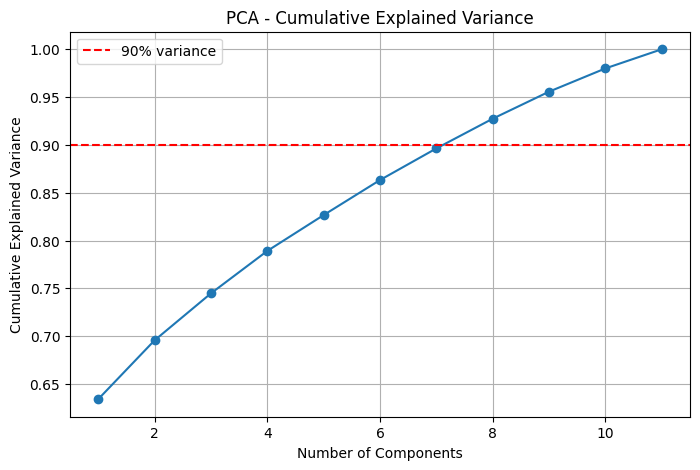

Components for 90% variance: 8


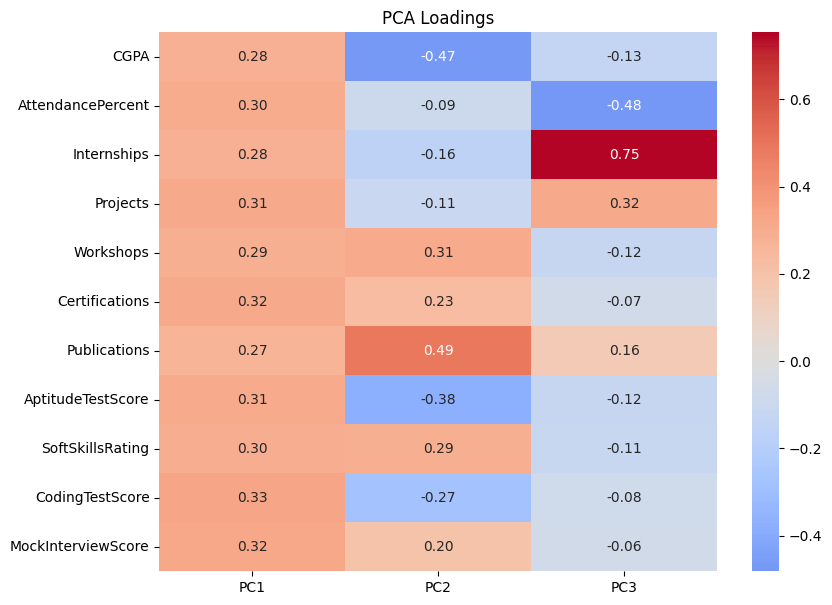

Running t-SNE with perplexity=5...
Running t-SNE with perplexity=30...
Running t-SNE with perplexity=50...


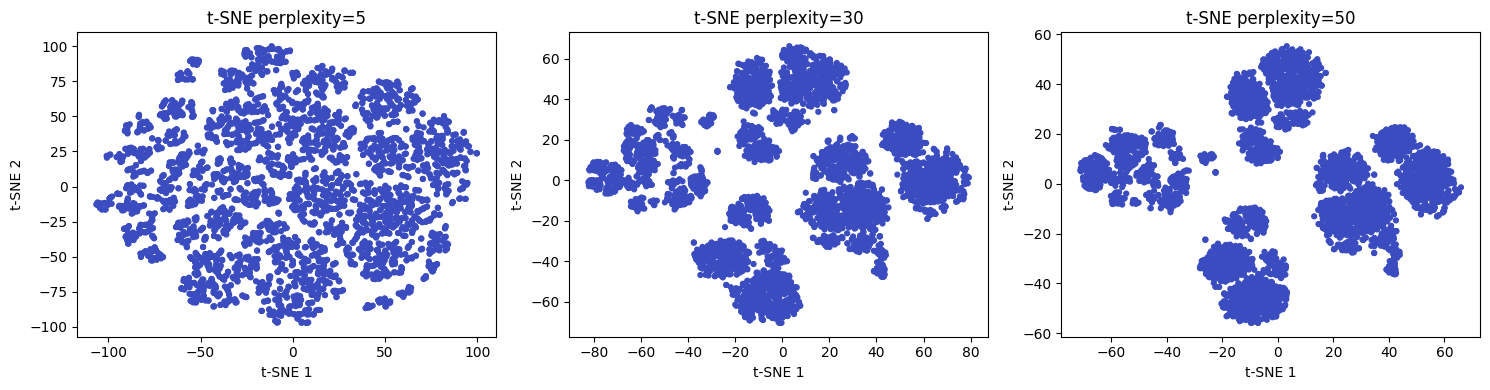


Running anomaly detection...

========== ANOMALY COUNTS ==========
IsolationForest   : 2500 anomalies
LOF               : 2500 anomalies
OneClassSVM       : 2501 anomalies


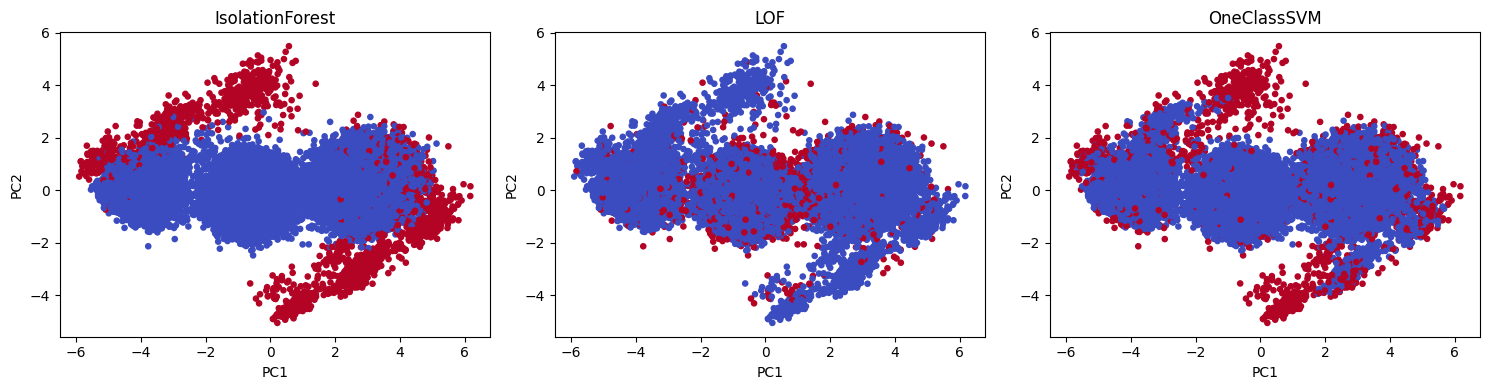


Flagged by >=2 methods: 1886

Mean feature values of consensus anomalies:
CGPA                   7.30
AttendancePercent     72.43
Internships            1.68
Projects               2.97
Workshops              1.99
Certifications         2.16
Publications           0.93
AptitudeTestScore     69.02
SoftSkillsRating       3.29
CodingTestScore       57.19
MockInterviewScore    59.37
dtype: float64

========== FIRST 10 CONSENSUS ANOMALIES ==========
     CGPA  AttendancePercent  Internships  Projects  Workshops  \
29   9.86          92.300000            3         1        2.0   
79   9.71          98.400000            1         3        3.0   
108  7.84          78.300000            3         2        3.0   
143  9.75          73.200000            3         5        3.0   
157  4.44          51.193717            0         2        2.0   
184  4.05          52.660174            2         2        NaN   
191  9.79          63.200000            3         5        0.0   
196  4.00          74.

In [ ]:
# ============================================================
# Experiment 10 : Dimensionality Reduction and Anomaly Detection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM


# ============================================================
# 1. LOAD PLACEMENT PREDICTION DATASET
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Loaded file:", filename)
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. SELECT FEATURES
# ============================================================

F = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]


# ============================================================
# 3. PREPARE DATA
# ============================================================

X_data = df[F].copy()

# Handle missing values
X_data = X_data.fillna(X_data.median())


# ============================================================
# 4. STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(X_data)

print("\nScaling completed.")


# ============================================================
# 5. PCA
# ============================================================

pca = PCA()

pca.fit(X)

cum = np.cumsum(
    pca.explained_variance_ratio_
)


# ============================================================
# 6. CUMULATIVE VARIANCE / SCREE PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cum) + 1),
    cum,
    'o-'
)

plt.axhline(
    0.90,
    color='r',
    linestyle='--',
    label='90% variance'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 7. COMPONENTS REQUIRED FOR 90% VARIANCE
# ============================================================

components_90 = int(
    np.argmax(cum >= 0.90) + 1
)

print(
    "Components for 90% variance:",
    components_90
)


# ============================================================
# 8. PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=F,
    columns=[
        "PC1",
        "PC2",
        "PC3"
    ]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")

plt.show()


# ============================================================
# 9. PCA 2D REPRESENTATION
# ============================================================

pca2 = PCA(
    n_components=2,
    random_state=0
)

X2 = pca2.fit_transform(X)


# ============================================================
# 10. PLACEMENT STATUS FOR VISUALIZATION
# ============================================================

y = (
    df["PlacementStatus"]
    .astype(str)
    .str.lower()
    .map({
        "placed": 1,
        "not placed": 0,
        "not_placed": 0
    })
)

# Handle any unexpected values
y = y.fillna(0)


# ============================================================
# 11. t-SNE
# ============================================================

# t-SNE is expensive for 50,000 records.
# Therefore use a random sample of 5,000 students.

sample_size = min(
    5000,
    len(X)
)

rng = np.random.RandomState(0)

sample_idx = rng.choice(
    len(X),
    sample_size,
    replace=False
)

X_tsne = X[sample_idx]

y_tsne = y.iloc[sample_idx].values


fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)


for a, perp in zip(
    ax,
    [5, 30, 50]
):

    print(
        f"Running t-SNE with perplexity={perp}..."
    )

    e = TSNE(
        n_components=2,
        perplexity=perp,
        init="pca",
        random_state=0
    ).fit_transform(X_tsne)

    a.scatter(
        e[:, 0],
        e[:, 1],
        c=y_tsne,
        cmap="coolwarm",
        s=12
    )

    a.set_title(
        f"t-SNE perplexity={perp}"
    )

    a.set_xlabel("t-SNE 1")
    a.set_ylabel("t-SNE 2")


plt.tight_layout()

plt.show()


# ============================================================
# 12. ANOMALY DETECTION
# ============================================================

print("\nRunning anomaly detection...")


flags = {

    "IsolationForest":
        IsolationForest(
            contamination=0.05,
            random_state=0
        ).fit_predict(X),

    "LOF":
        LocalOutlierFactor(
            n_neighbors=20,
            contamination=0.05
        ).fit_predict(X),

    "OneClassSVM":
        OneClassSVM(
            nu=0.05,
            gamma="scale"
        ).fit(X).predict(X)

}


# ============================================================
# 13. DISPLAY NUMBER OF ANOMALIES
# ============================================================

print("\n========== ANOMALY COUNTS ==========")

for name, prediction in flags.items():

    print(
        f"{name:<18}: "
        f"{(prediction == -1).sum()} anomalies"
    )


# ============================================================
# 14. VISUALIZE ANOMALIES USING PCA
# ============================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)


for a, (name, prediction) in zip(
    ax,
    flags.items()
):

    a.scatter(
        X2[:, 0],
        X2[:, 1],
        c=(prediction == -1),
        cmap="coolwarm",
        s=14
    )

    a.set_title(name)

    a.set_xlabel("PC1")
    a.set_ylabel("PC2")


plt.tight_layout()

plt.show()


# ============================================================
# 15. CONSENSUS ANOMALIES
# ============================================================

flag_df = pd.DataFrame(flags)

consensus = (
    (flag_df == -1).sum(axis=1) >= 2
)


print(
    "\nFlagged by >=2 methods:",
    consensus.sum()
)


# ============================================================
# 16. MEAN VALUES OF CONSENSUS ANOMALIES
# ============================================================

print(
    "\nMean feature values of consensus anomalies:"
)

print(
    df.loc[
        consensus,
        F
    ].mean().round(2)
)


# ============================================================
# 17. DISPLAY FIRST 10 ANOMALOUS STUDENTS
# ============================================================

anomalies = df.loc[
    consensus,
    F + [
        "PlacementStatus",
        "IsAnomaly"
    ]
]


print(
    "\n========== FIRST 10 CONSENSUS ANOMALIES =========="
)

print(
    anomalies.head(10)
)


# ============================================================
# 18. COMPARE DETECTED ANOMALIES WITH DATASET IsAnomaly
# ============================================================

print(
    "\n========== DATASET ANOMALY LABEL =========="
)

print(
    df["IsAnomaly"].value_counts()
)


# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n========== EXPERIMENT 10 SUMMARY ==========")

print(
    "Dataset size:",
    df.shape
)

print(
    "Features used:",
    len(F)
)

print(
    "Components for 90% variance:",
    components_90
)

print(
    "Isolation Forest anomalies:",
    (flags["IsolationForest"] == -1).sum()
)

print(
    "LOF anomalies:",
    (flags["LOF"] == -1).sum()
)

print(
    "One-Class SVM anomalies:",
    (flags["OneClassSVM"] == -1).sum()
)

print(
    "Consensus anomalies:",
    consensus.sum()
)